# 05 — Negative controls

A negative control is an experiment whose result is known in advance if the
pipeline is sound. When one fails, the pipeline is measuring something other
than what it claims to.

| control | expected if the model is measuring voice pathology |
|---|---|
| Demographics only (age + sex) | near chance — matched by design |
| Label permutation | AUROC distribution centred on 0.5 |
| Batch discrimination **within** PD | near chance — same disease, same label |
| Silence only | near chance — contains no speech |

The third is the decisive one. It holds the diagnosis fixed and asks whether the
recording campaign is recoverable from the audio. If it is, the campaign is a
usable shortcut wherever campaign and diagnosis are correlated — which in this
corpus they are.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Walk up to the repository root so this runs identically from notebooks/,
# scripts/, or the repository root itself.
ROOT = Path.cwd().resolve()
while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src import experiment as E  # noqa: E402
from src import metrics as M  # noqa: E402
from src import splits as S  # noqa: E402
from src import viz as V  # noqa: E402

V.use_house_style()
pd.set_option("display.width", 170)

FEATURE_DIR = ROOT / "data" / "processed" / "features"
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
controls = []

## Control 1 — Demographics only

Age and sex, no audio. Notebook 02 showed age is closely matched (Welch p =
0.89) and sex is not balanced (64% vs 46% male), so a small amount of
information is expected here. It sets the floor that any acoustic model must
clear to be interesting.

In [2]:
_, y_full, meta_full = E.load_features(FEATURE_DIR, "read_text", "mfcc", "full")

demographic_pipeline = Pipeline(
    [
        (
            "encode",
            ColumnTransformer(
                [
                    ("age", StandardScaler(), ["age"]),
                    ("sex", OneHotEncoder(drop="first"), ["sex"]),
                ]
            ),
        ),
        ("clf", LogisticRegression(max_iter=1000)),
    ]
)


def run_demographics(meta: pd.DataFrame, y: np.ndarray, label: str) -> dict:
    X = meta[["age", "sex"]]
    oof = np.full(len(y), np.nan)
    for _, train_idx, test_idx in S.iter_splits(meta, y, "C_subject_key", n_repeats=1):
        model = Pipeline(demographic_pipeline.steps)
        model.fit(X.iloc[train_idx], y[train_idx])
        oof[test_idx] = model.predict_proba(X.iloc[test_idx])[:, 1]
    part = M.aggregate_to_participant(meta["subject_id"].to_numpy(), y, oof)
    point, lo, hi = M.bootstrap_auroc_ci(
        part["y_true"].to_numpy(), part["y_score"].to_numpy()
    )
    return {"control": f"age + sex only ({label})", "auroc": point, "ci_lo": lo,
            "ci_hi": hi, "n": len(part)}


controls.append(run_demographics(meta_full, y_full, "full"))
_, y_m, meta_m = E.load_features(FEATURE_DIR, "read_text", "mfcc", "batch_matched")
controls.append(run_demographics(meta_m, y_m, "batch_matched"))
print(pd.DataFrame(controls).round(3).to_string(index=False))

                       control  auroc  ci_lo  ci_hi  n
         age + sex only (full)  0.574  0.404  0.754 46
age + sex only (batch_matched)  0.618  0.431  0.802 39


## Control 2 — Batch discrimination within the patient group

Only PD participants, so the diagnosis is constant. The target is the recording
campaign. A model that succeeds here is reading acquisition conditions, and
nothing else is available to it.

The three participants recorded in both campaigns are excluded, so the model
cannot recognise a person instead of a campaign.

In [3]:
frame = pd.read_parquet(FEATURE_DIR / "read_text__mfcc.parquet")
pd_only = frame[frame["group"] == "PD"].copy()

both_campaigns = (
    pd_only.groupby("subject_id")["batch"].nunique().loc[lambda s: s > 1].index
)
pd_only = pd_only[~pd_only["subject_id"].isin(both_campaigns)].reset_index(drop=True)

y_batch = (pd_only["batch"] == "2016_batch").astype(int).to_numpy()
X_batch = pd_only.iloc[:, 13:]
meta_batch = pd_only.iloc[:, :13]

print(
    f"PD participants only, excluding {len(both_campaigns)} recorded in both "
    f"campaigns: {meta_batch['subject_id'].nunique()} participants, "
    f"{len(pd_only)} recordings"
)
print(f"  2016 campaign: {int(y_batch.sum())} recordings")
print(f"  2017 campaign: {int((1 - y_batch).sum())} recordings")

batch_result = E.run_arm(X_batch, y_batch, meta_batch, "C_subject_key", n_repeats=5)
point, lo, hi = batch_result["auroc_participant"]
controls.append(
    {
        "control": "recording campaign, within PD only",
        "auroc": point,
        "ci_lo": lo,
        "ci_hi": hi,
        "n": meta_batch["subject_id"].nunique(),
    }
)
print(f"\nAUROC for predicting the campaign among patients: {point:.3f} [{lo:.3f}, {hi:.3f}]")

PD participants only, excluding 3 recorded in both campaigns: 22 participants, 40 recordings
  2016 campaign: 14 recordings
  2017 campaign: 26 recordings



AUROC for predicting the campaign among patients: 0.352 [0.111, 0.614]


This control is **inconclusive, not negative**. Excluding the participants
recorded twice leaves 22 patients split roughly 8 / 14 between campaigns, and
the interval spans chance in both directions. It cannot establish that no
campaign signature exists.

What it does do is redirect the explanation. Notebook 03 showed that restricting
to a single campaign and a single sample rate leaves the silence-only control at
AUROC 1.000. If the acquisition difference were a property of the *year*, that
restriction would have removed it. It did not. So the difference tracks the
**group**: patients and controls were recorded under systematically different
conditions within the same campaign — a different room, microphone, distance or
gain — and the sample-rate split merely made the existence of two setups visible.

## Control 3 — Label permutation

Labels are shuffled **at participant level**, preserving the fact that a
participant's recordings share a label. The resulting distribution is what the
pipeline reports when there is nothing to find. If it is centred well above 0.5,
the evaluation itself is broken.

Run on the correct split (arm C) and, for contrast, on the recording-level split
(arm A) where a shuffled label still travels with the participant.

This is where the cost of a recording-level split becomes measurable. The main
grid could not show it: with the real labels every arm sits at 1.000, so there is
no headroom for leakage to occupy. Removing the real signal by shuffling exposes
how much of the reported score a leaky split can manufacture on its own.

In [4]:
def make_fit_predict(X: pd.DataFrame, arm: str):
    X_values = X.to_numpy()

    def fit_predict(meta: pd.DataFrame, y: np.ndarray):
        oof = np.full(len(y), np.nan)
        for _, train_idx, test_idx in S.iter_splits(meta, y, arm, n_repeats=1):
            model = E.default_estimator(42)
            model.fit(X_values[train_idx], y[train_idx])
            oof[test_idx] = model.predict_proba(X_values[test_idx])[:, 1]
        part = M.aggregate_to_participant(meta["subject_id"].to_numpy(), y, oof)
        return part["y_true"].to_numpy(), part["y_score"].to_numpy()

    return fit_predict


X_m, y_m, meta_m = E.load_features(FEATURE_DIR, "read_text", "mfcc", "batch_matched")

N_PERM = 500  # 500 gives a resolution of 0.002 on the p-value; 1000 doubles runtime
permutations = {}
for arm in ("C_subject_key", "A_recording"):
    print(f"permutation test, {arm} ({N_PERM} shuffles)...")
    permutations[arm] = M.permutation_test(
        make_fit_predict(X_m, arm), meta_m, y_m, n_perm=N_PERM, seed=42
    )
    result = permutations[arm]
    print(
        f"  observed {result['observed']:.3f} | null mean {result['null_mean']:.3f} "
        f"| null 95th pct {result['null_p95']:.3f} | p = {result['p_value']:.4f}"
    )
    controls.append(
        {
            "control": f"label permutation null mean ({arm})",
            "auroc": result["null_mean"],
            "ci_lo": float(np.quantile(result["null"], 0.025)),
            "ci_hi": float(np.quantile(result["null"], 0.975)),
            "n": meta_m["subject_id"].nunique(),
        }
    )

permutation test, C_subject_key (500 shuffles)...


  observed 1.000 | null mean 0.447 | null 95th pct 0.647 | p = 0.0020
permutation test, A_recording (500 shuffles)...


  observed 1.000 | null mean 0.882 | null 95th pct 0.958 | p = 0.0020


## Control 4 — Silence only

Carried over from the main grid so all four controls appear in one place.

In [5]:
grid = pd.read_parquet(RESULTS / "grid.parquet")
silence = grid[
    (grid["feature_set"] == "silence")
    & (grid["arm"] == "C_subject_key")
    & (grid["task"] == "read_text")
]
for row in silence.itertuples():
    controls.append(
        {
            "control": f"silence only, no speech ({row.cohort})",
            "auroc": row.auroc_participant,
            "ci_lo": row.ci_lo,
            "ci_hi": row.ci_hi,
            "n": row.n_participants,
        }
    )

control_table = pd.DataFrame(controls)
control_table.to_parquet(RESULTS / "negative_controls.parquet", index=False)
print(control_table.round(3).to_string(index=False))

                                    control  auroc  ci_lo  ci_hi  n
                      age + sex only (full)  0.574  0.404  0.754 46
             age + sex only (batch_matched)  0.618  0.431  0.802 39
         recording campaign, within PD only  0.352  0.111  0.614 22
label permutation null mean (C_subject_key)  0.446  0.216  0.680 39
  label permutation null mean (A_recording)  0.882  0.778  0.970 39
             silence only, no speech (full)  1.000  1.000  1.000 46
    silence only, no speech (batch_matched)  1.000  1.000  1.000 39


## Figure 10 — All controls together

The reference model (read passage, MFCC, correct split) is shown at the top.
Controls that should sit at chance are marked.

  saved fig10_negative_controls.png (+ .pdf)


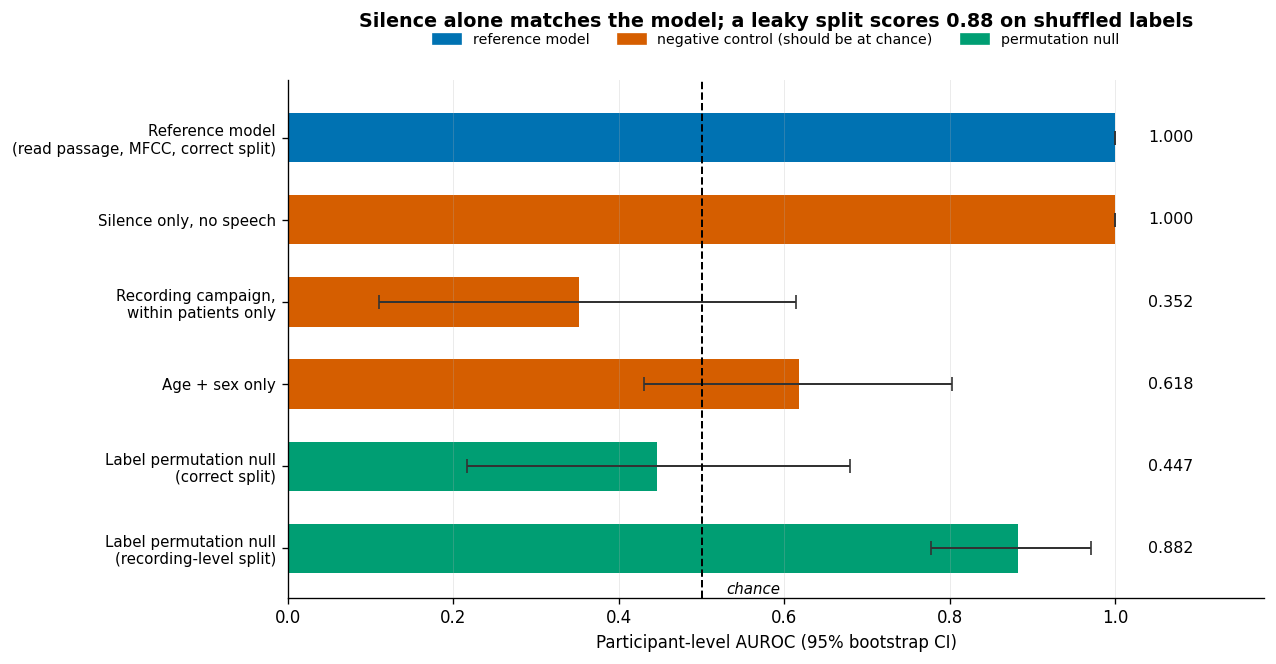

In [6]:
reference = grid[
    (grid["feature_set"] == "mfcc")
    & (grid["arm"] == "C_subject_key")
    & (grid["task"] == "read_text")
    & (grid["cohort"] == "batch_matched")
].iloc[0]

plot_rows = [
    {
        "label": "Reference model\n(read passage, MFCC, correct split)",
        "auroc": reference["auroc_participant"],
        "lo": reference["ci_lo"],
        "hi": reference["ci_hi"],
        "kind": "model",
    }
]
expectations = {
    "silence only, no speech (batch_matched)": ("Silence only, no speech", "control"),
    "recording campaign, within PD only": (
        "Recording campaign,\nwithin patients only",
        "control",
    ),
    "age + sex only (batch_matched)": ("Age + sex only", "control"),
    "label permutation null mean (C_subject_key)": (
        "Label permutation null\n(correct split)",
        "null",
    ),
    "label permutation null mean (A_recording)": (
        "Label permutation null\n(recording-level split)",
        "null",
    ),
}
for key, (label, kind) in expectations.items():
    row = control_table[control_table["control"] == key]
    if len(row):
        row = row.iloc[0]
        plot_rows.append(
            {"label": label, "auroc": row["auroc"], "lo": row["ci_lo"],
             "hi": row["ci_hi"], "kind": kind}
        )

plot_df = pd.DataFrame(plot_rows)[::-1].reset_index(drop=True)
colours = {"model": "#0072B2", "control": "#D55E00", "null": "#009E73"}

fig, ax = plt.subplots(figsize=(10.5, 5.6))
positions = np.arange(len(plot_df))
ax.barh(
    positions,
    plot_df["auroc"],
    xerr=[plot_df["auroc"] - plot_df["lo"], plot_df["hi"] - plot_df["auroc"]],
    color=[colours[k] for k in plot_df["kind"]],
    height=0.6,
    capsize=4,
    error_kw={"linewidth": 1.2, "ecolor": "#333333"},
)
label_x = plot_df["hi"].max() + 0.04
for pos, value in zip(positions, plot_df["auroc"]):
    ax.text(label_x, pos, f"{value:.3f}", va="center", fontsize=9.5)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2)
ax.set_yticks(positions)
ax.set_yticklabels(plot_df["label"], fontsize=9)
ax.set_xlabel("Participant-level AUROC (95% bootstrap CI)")
ax.set_xlim(0, 1.18)
ax.set_ylim(-0.6, len(plot_df) - 0.3)
ax.grid(axis="y", visible=False)
ax.annotate(
    "chance",
    xy=(0.5, -0.5),
    xytext=(0.53, -0.5),
    fontsize=9,
    style="italic",
    va="center",
)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=colours[k])
    for k in ("model", "control", "null")
]
ax.legend(
    handles,
    ["reference model", "negative control (should be at chance)", "permutation null"],
    fontsize=8.5,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=3,
)
ax.set_title(
    "Silence alone matches the model; a leaky split scores 0.88 on shuffled labels",
    fontsize=11.5,
    fontweight="bold",
    pad=32,
)
V.save_fig(
    fig,
    "fig10_negative_controls",
    "Negative controls. Demographics sit near chance and the permutation null is "
    "correctly centred under the participant-level split. Two results are not as "
    "expected: silence containing no speech reaches AUROC 1.000, and the "
    "permutation null under a recording-level split rises to 0.88.",
)
plt.show()

Reading the figure from the bottom up:

- **Age + sex** sits near chance, so demographics are not the explanation.
- **Permutation null, correct split** is centred just below 0.5, which is the
  evidence that the evaluation machinery itself is sound.
- **Permutation null, recording-level split** rises to 0.88. With labels assigned
  at random, a recording-level split still reports AUROC 0.88, because the model
  recognises the participant and recalls whichever label they were given. This is
  the quantity that a published recording-level result cannot distinguish from a
  real effect.
- **Silence only** reaches 1.000 and should be at chance.

## Figure 11 — Permutation null distributions

The two panels show why a recording-level split cannot be diagnosed by looking
at the observed score alone: it inflates the *null* as well.

  saved fig11_permutation.png (+ .pdf)


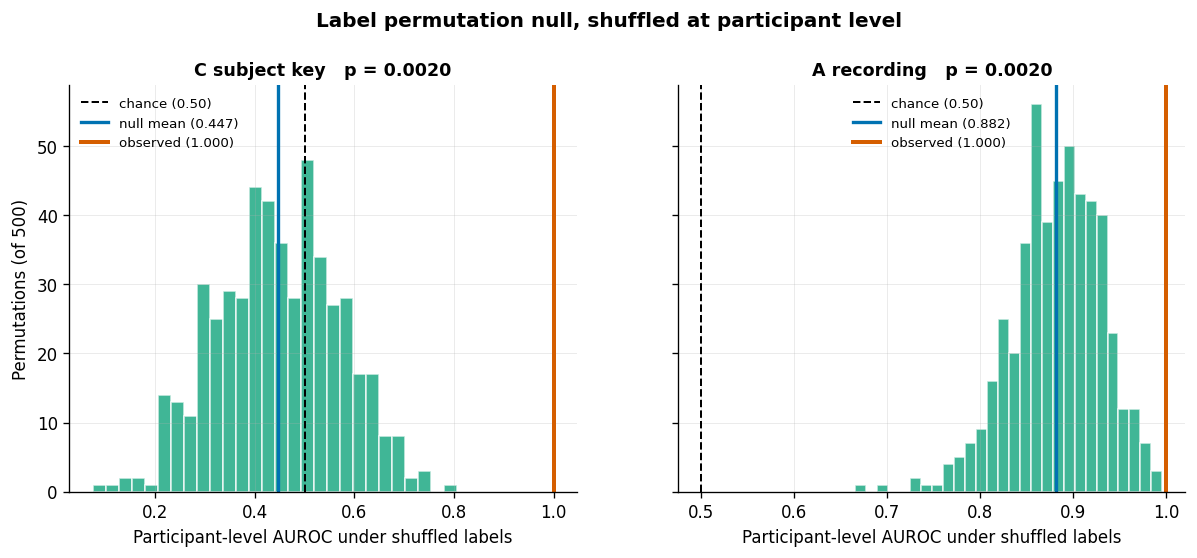

C_subject_key   observed 1.000  null mean 0.447  null 95th 0.647  p = 0.0020
A_recording     observed 1.000  null mean 0.882  null 95th 0.958  p = 0.0020


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, arm in zip(axes, ("C_subject_key", "A_recording")):
    result = permutations[arm]
    ax.hist(result["null"], bins=28, color="#009E73", alpha=0.75, edgecolor="white")
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="chance (0.50)")
    ax.axvline(
        result["null_mean"], color="#0072B2", linewidth=2,
        label=f"null mean ({result['null_mean']:.3f})",
    )
    ax.axvline(
        result["observed"], color="#D55E00", linewidth=2.4,
        label=f"observed ({result['observed']:.3f})",
    )
    ax.set_xlabel("Participant-level AUROC under shuffled labels")
    ax.set_title(f"{arm.replace('_', ' ')}   p = {result['p_value']:.4f}", fontsize=10.5)
    ax.legend(fontsize=8)
axes[0].set_ylabel(f"Permutations (of {N_PERM})")
fig.suptitle(
    "Label permutation null, shuffled at participant level",
    fontsize=12, fontweight="bold", y=1.02,
)
V.save_fig(
    fig, "fig11_permutation",
    "Null distribution of participant-level AUROC under participant-level label "
    "shuffling, for the correct and the recording-level split.",
)
plt.show()

for arm, result in permutations.items():
    print(
        f"{arm:15s} observed {result['observed']:.3f}  null mean "
        f"{result['null_mean']:.3f}  null 95th {result['null_p95']:.3f}  "
        f"p = {result['p_value']:.4f}"
    )